In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load daily store performance data created in SQL
store = pd.read_csv("store_performance.csv")

# Convert Date to datetime format
store["Date"] = pd.to_datetime(store["Date"])

# Check dataset structure
print("Dataset shape:", store.shape)
store.head()

Dataset shape: (43544, 14)


,Date,Year,Quarter,Month_Number,Month_Name,Store_ID,Store_Name,Store_City,Store_Location,Units_Sold,Revenue,COGS,Gross_Profit,Gross_Margin
0,2025-01-01,2025,1,1,January,1,Maple Street Toys Louisville 1,"Louisville, KY",Downtown,13,183.67,106.36,77.31,0.420918
1,2025-01-01,2025,1,1,January,2,Puzzle Planet San Antonio 1,"San Antonio, TX",Commercial,6,89.19,46.00,43.19,0.484247
2,2025-01-01,2025,1,1,January,3,Wonderland Toys Orlando 1,"Orlando, FL",Mall,4,84.54,50.90,33.64,0.397918
3,2025-01-01,2025,1,1,January,4,Spark & Play St. Paul 1,"St. Paul, MN",Downtown,22,427.04,228.45,198.59,0.465038
4,2025-01-01,2025,1,1,January,5,Tiny Treasures Toys Riverside 1,"Riverside, CA",Residential,1,19.53,9.32,10.21,0.522785


In [3]:
# Check data types and missing values
store.info()

print("\nMissing values:")
print(store.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43544 entries, 0 to 43543
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            43544 non-null  datetime64[ns]
 1   Year            43544 non-null  int64         
 2   Quarter         43544 non-null  int64         
 3   Month_Number    43544 non-null  int64         
 4   Month_Name      43544 non-null  object        
 5   Store_ID        43544 non-null  int64         
 6   Store_Name      43544 non-null  object        
 7   Store_City      43544 non-null  object        
 8   Store_Location  43544 non-null  object        
 9   Units_Sold      43544 non-null  int64         
 10  Revenue         43544 non-null  float64       
 11  COGS            43544 non-null  float64       
 12  Gross_Profit    43544 non-null  float64       
 13  Gross_Margin    43544 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(5), object(4)


In [4]:
# Aggregate store performance across the full year
store_summary = (
    store.groupby(
        ["Store_ID", "Store_Name", "Store_City", "Store_Location"],
        as_index=False
    )
    .agg(
        Units_Sold=("Units_Sold", "sum"),
        Revenue=("Revenue", "sum"),
        COGS=("COGS", "sum"),
        Gross_Profit=("Gross_Profit", "sum")
    )
)

# Calculate gross margin at the annual store level
store_summary["Gross_Margin"] = (
    store_summary["Gross_Profit"] / store_summary["Revenue"]
)

# Sort stores by revenue
store_summary = store_summary.sort_values(
    "Revenue",
    ascending=False
)

store_summary.head(10)

,Store_ID,Store_Name,Store_City,Store_Location,Units_Sold,Revenue,COGS,Gross_Profit,Gross_Margin
33,34,Sunshine Toy Store Arlington 1,"Arlington, TX",Downtown,5796,103824.10,58320.03,45504.07,0.438280
14,15,Bluebird Toys Lexington 1,"Lexington, KY",Downtown,6002,102623.94,57718.55,44905.39,0.437572
102,103,Toy Haven Akron 1,"Akron, OH",Downtown,5735,102152.67,57833.51,44319.16,0.433852
0,1,Maple Street Toys Louisville 1,"Louisville, KY",Downtown,5698,102045.91,57521.56,44524.35,0.436317
114,115,Mountain Trail Toys Pittsburgh 1,"Pittsburgh, PA",Downtown,5621,101236.05,56611.24,44624.81,0.440800
34,35,Playtime Emporium Fort Worth 1,"Fort Worth, TX",Commercial,5657,101151.19,56791.59,44359.60,0.438547
85,86,Maple Street Toys Des Moines 1,"Des Moines, IA",Commercial,5615,99965.25,56553.34,43411.91,0.434270
73,74,Creative Play Toys Huntsville 1,"Huntsville, AL",Downtown,6036,98942.13,55195.58,43746.55,0.442143
84,85,Cedar Toy Corner Montgomery 1,"Montgomery, AL",Downtown,5729,98668.57,55860.63,42807.94,0.433856
46,47,Neighborhood Toy Co. Worcester 1,"Worcester, MA",Mall,5727,98042.97,55416.94,42626.03,0.434769


In [5]:
# Display the top 10 stores by annual revenue
top_stores = store_summary.head(10)

top_stores[
    [
        "Store_Name",
        "Store_City",
        "Units_Sold",
        "Revenue",
        "Gross_Profit",
        "Gross_Margin"
    ]
]

,Store_Name,Store_City,Units_Sold,Revenue,Gross_Profit,Gross_Margin
33,Sunshine Toy Store Arlington 1,"Arlington, TX",5796,103824.10,45504.07,0.438280
14,Bluebird Toys Lexington 1,"Lexington, KY",6002,102623.94,44905.39,0.437572
102,Toy Haven Akron 1,"Akron, OH",5735,102152.67,44319.16,0.433852
0,Maple Street Toys Louisville 1,"Louisville, KY",5698,102045.91,44524.35,0.436317
114,Mountain Trail Toys Pittsburgh 1,"Pittsburgh, PA",5621,101236.05,44624.81,0.440800
34,Playtime Emporium Fort Worth 1,"Fort Worth, TX",5657,101151.19,44359.60,0.438547
85,Maple Street Toys Des Moines 1,"Des Moines, IA",5615,99965.25,43411.91,0.434270
73,Creative Play Toys Huntsville 1,"Huntsville, AL",6036,98942.13,43746.55,0.442143
84,Cedar Toy Corner Montgomery 1,"Montgomery, AL",5729,98668.57,42807.94,0.433856
46,Neighborhood Toy Co. Worcester 1,"Worcester, MA",5727,98042.97,42626.03,0.434769


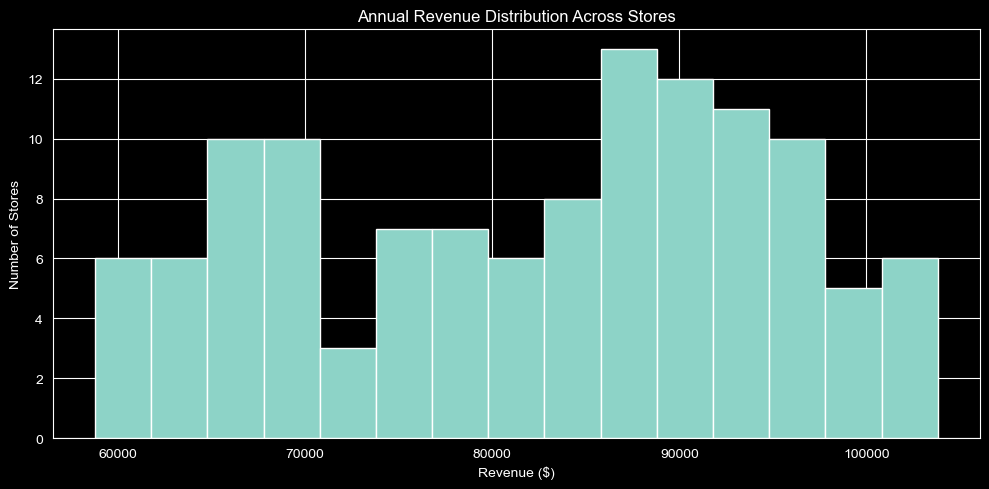

In [6]:
# Plot annual revenue distribution across stores
plt.figure(figsize=(10, 5))
plt.hist(store_summary["Revenue"], bins=15)
plt.title("Annual Revenue Distribution Across Stores")
plt.xlabel("Revenue ($)")
plt.ylabel("Number of Stores")
plt.tight_layout()
plt.show()

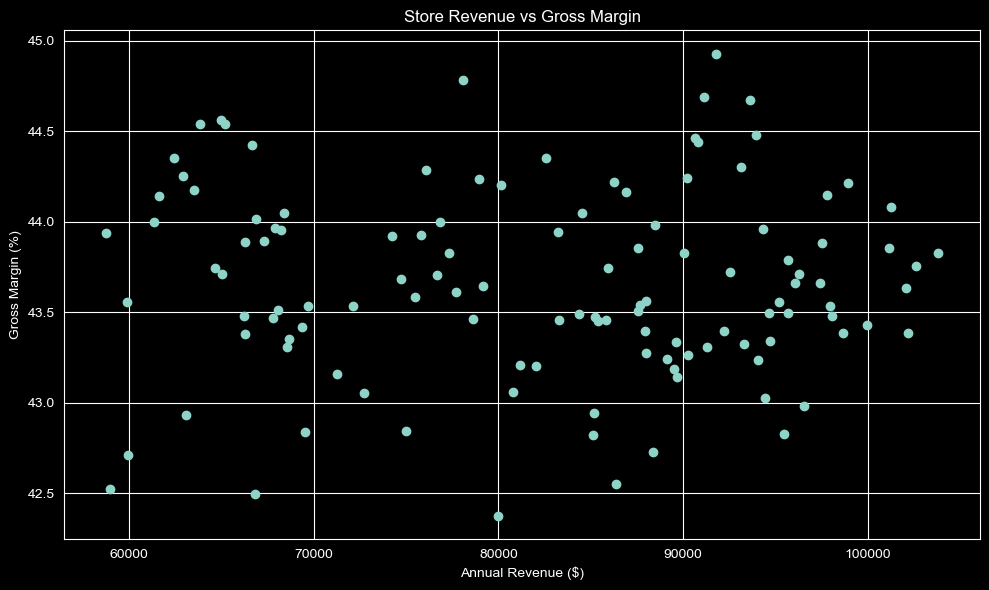

In [7]:
# Plot store revenue against gross margin
plt.figure(figsize=(10, 6))
plt.scatter(
    store_summary["Revenue"],
    store_summary["Gross_Margin"] * 100
)
plt.title("Store Revenue vs Gross Margin")
plt.xlabel("Annual Revenue ($)")
plt.ylabel("Gross Margin (%)")
plt.tight_layout()
plt.show()

In [8]:
# Compare the top and bottom 10 stores by annual revenue
top_10 = store_summary.nlargest(10, "Revenue")
bottom_10 = store_summary.nsmallest(10, "Revenue")

print("Top 10 Stores - Average Metrics")
print(top_10[["Units_Sold", "Revenue", "Gross_Profit", "Gross_Margin"]].mean())

print("\nBottom 10 Stores - Average Metrics")
print(bottom_10[["Units_Sold", "Revenue", "Gross_Profit", "Gross_Margin"]].mean())

Top 10 Stores - Average Metrics
Units_Sold        5761.600000
Revenue         100865.278000
Gross_Profit     44082.981000
Gross_Margin         0.437041
dtype: float64

Bottom 10 Stores - Average Metrics
Units_Sold       3570.000000
Revenue         61254.869000
Gross_Profit    26748.226000
Gross_Margin        0.436587
dtype: float64


In [9]:
# Analyze the relationship between annual units sold and revenue
correlation = store_summary["Units_Sold"].corr(
    store_summary["Revenue"]
)

print(f"Correlation between Units Sold and Revenue: {correlation:.3f}")

Correlation between Units Sold and Revenue: 0.975


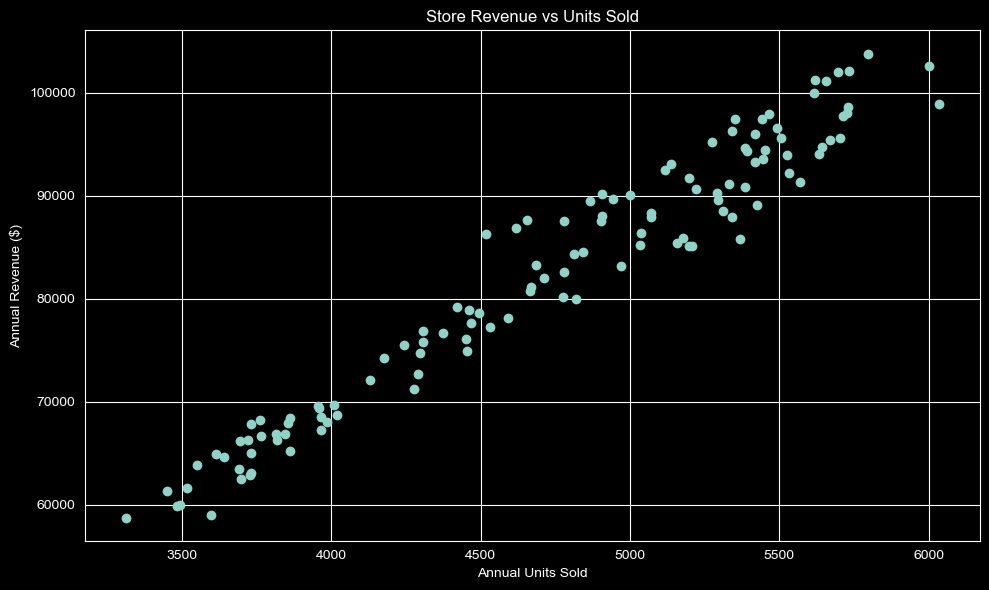

In [10]:
# Plot annual units sold against revenue for all stores
plt.figure(figsize=(10, 6))
plt.scatter(
    store_summary["Units_Sold"],
    store_summary["Revenue"]
)
plt.title("Store Revenue vs Units Sold")
plt.xlabel("Annual Units Sold")
plt.ylabel("Annual Revenue ($)")
plt.tight_layout()
plt.show()

In [11]:
# Identify the top 5 stores by annual revenue
top_5_store_ids = (
    store_summary
    .nlargest(5, "Revenue")["Store_ID"]
    .tolist()
)

print("Top 5 Store IDs:", top_5_store_ids)

# Filter daily store performance for the top 5 stores
top_5_daily = store[
    store["Store_ID"].isin(top_5_store_ids)
].copy()

# Create a monthly revenue dataset for the top 5 stores
top_5_monthly = (
    top_5_daily
    .groupby(
        ["Month_Number", "Month_Name", "Store_ID", "Store_Name"],
        as_index=False
    )
    .agg(
        Revenue=("Revenue", "sum"),
        Units_Sold=("Units_Sold", "sum"),
        Gross_Profit=("Gross_Profit", "sum")
    )
)

# Sort by month and store
top_5_monthly = top_5_monthly.sort_values(
    ["Month_Number", "Store_ID"]
)

top_5_monthly.head(10)

Top 5 Store IDs: [34, 15, 103, 1, 115]


,Month_Number,Month_Name,Store_ID,Store_Name,Revenue,Units_Sold,Gross_Profit
0,1,January,1,Maple Street Toys Louisville 1,8785.99,482,3867.25
1,1,January,15,Bluebird Toys Lexington 1,10272.06,580,4460.26
2,1,January,34,Sunshine Toy Store Arlington 1,7197.33,403,3087.22
3,1,January,103,Toy Haven Akron 1,7695.09,430,3341.19
4,1,January,115,Mountain Trail Toys Pittsburgh 1,9717.78,532,4232.36
5,2,February,1,Maple Street Toys Louisville 1,7971.59,434,3476.25
6,2,February,15,Bluebird Toys Lexington 1,8503.05,495,3727.19
7,2,February,34,Sunshine Toy Store Arlington 1,7837.37,442,3450.38
8,2,February,103,Toy Haven Akron 1,8485.68,495,3693.43
9,2,February,115,Mountain Trail Toys Pittsburgh 1,7266.15,383,3198.87


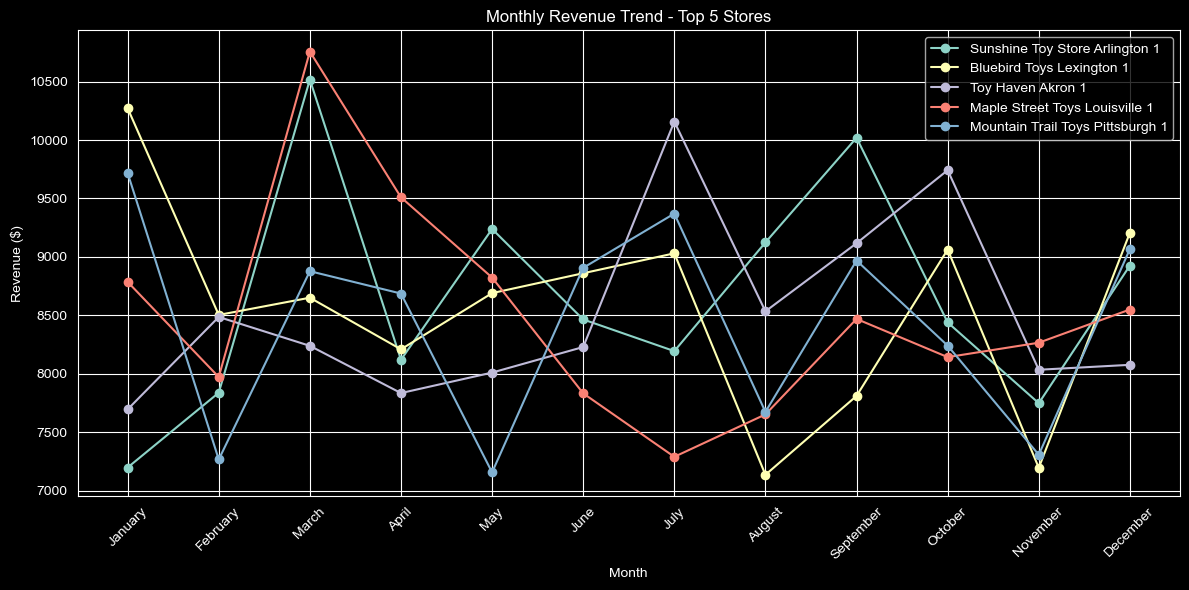

In [12]:
# Plot monthly revenue trends for the top 5 stores
plt.figure(figsize=(12, 6))

for store_id in top_5_store_ids:
    store_data = top_5_monthly[
        top_5_monthly["Store_ID"] == store_id
    ]
    plt.plot(
        store_data["Month_Name"],
        store_data["Revenue"],
        marker="o",
        label=store_data["Store_Name"].iloc[0]
    )

plt.title("Monthly Revenue Trend - Top 5 Stores")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Find the highest and lowest revenue month for each of the top 5 stores
store_month_extremes = (
    top_5_monthly
    .loc[
        top_5_monthly.groupby("Store_ID")["Revenue"].idxmax(),
        ["Store_Name", "Month_Name", "Revenue"]
    ]
    .rename(columns={"Revenue": "Highest_Month_Revenue"})
)

store_month_extremes["Lowest_Month_Revenue"] = (
    top_5_monthly
    .groupby("Store_ID")["Revenue"]
    .min()
    .values
)

store_month_extremes

,Store_Name,Month_Name,Highest_Month_Revenue,Lowest_Month_Revenue
10,Maple Street Toys Louisville 1,March,10756.97,7288.94
1,Bluebird Toys Lexington 1,January,10272.06,7135.12
12,Sunshine Toy Store Arlington 1,March,10517.41,7197.33
33,Toy Haven Akron 1,July,10157.86,7695.09
4,Mountain Trail Toys Pittsburgh 1,January,9717.78,7155.82


In [15]:
# Calculate total monthly revenue across all stores
monthly_store_revenue = (
    store
    .groupby(
        ["Month_Number", "Month_Name"],
        as_index=False
    )
    .agg(
        Revenue=("Revenue", "sum"),
        Units_Sold=("Units_Sold", "sum"),
        Gross_Profit=("Gross_Profit", "sum")
    )
    .sort_values("Month_Number")
)

monthly_store_revenue

,Month_Number,Month_Name,Revenue,Units_Sold,Gross_Profit
0,1,January,835079.93,48099,363526.99
1,2,February,763977.05,43845,333622.17
2,3,March,843263.00,48636,368103.46
3,4,April,808097.00,46534,352586.80
4,5,May,841799.81,48335,367152.09
5,6,June,821307.30,47229,358955.02
6,7,July,837831.87,48203,366360.42
7,8,August,820523.99,47060,358119.02
8,9,September,806311.19,46356,352560.35
9,10,October,839460.79,48352,367396.69


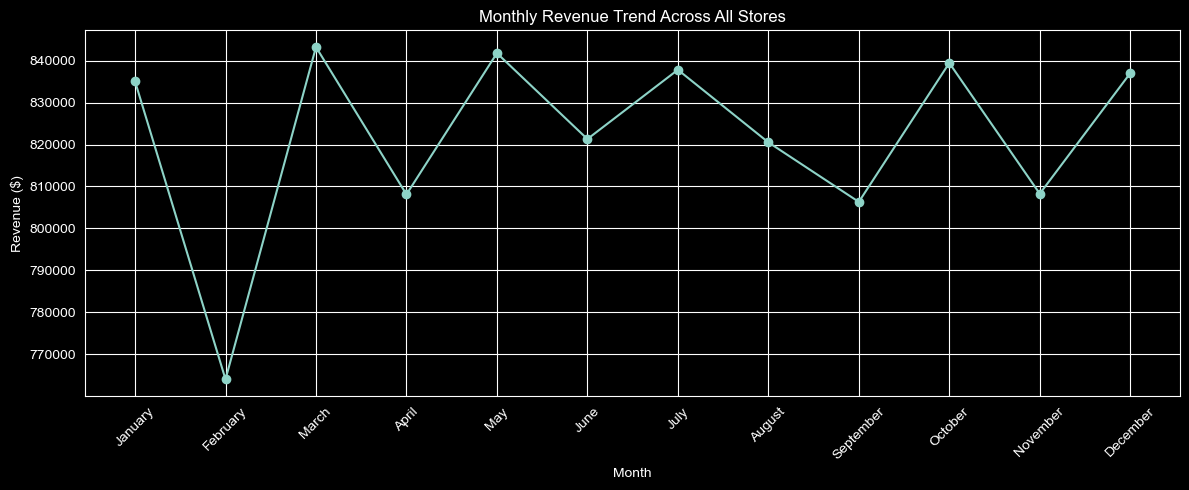

In [16]:
# Plot total monthly revenue across all stores
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_store_revenue["Month_Name"],
    monthly_store_revenue["Revenue"],
    marker="o"
)
plt.title("Monthly Revenue Trend Across All Stores")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()